Clasificación espectral II
==

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
La forma más sencilla de comenzar a estudiar un conjunto de objetos es clasificarlos en función de características comunes, es decir, elaborar su taxonomía. La forma de clasificar a las estrellas se basa en las características de sus espectros, por lo que la llamamos "clasificación espectral". La clasificación espectral divide las estrellas en tipos espectrales y, con un refinamiento posterior, en clases de luminosidad. No obstante, en muchas ocasiones hablamos de tipo espectral para referirnos a la combinación de ambos, el tipo espectral y la clase de luminosidad.

En esta práctica vamos a clasificar una serie de espectros estelares digitales comparando con los estándares provistos en el [“Spectral Classification Atlas”](http://ned.ipac.caltech.edu/level5/Gray/frames.html) de R.O. Gray.

Referencias
---
* [Práctica 06 (overleaf)](https://www.overleaf.com/read/qsjbtpsqtknt)

---

Ejercicios
---
Objetivos:
* Identificar las líneas espectrales presentes en al menos 3 espectros. Para esto, utilize los criterios provistos
por el atlas digital y clasifique cada espectro.

**1.** Cargamos los espectros

In [1]:
import glob
list = sorted ( glob.glob('*.fits') )

In [2]:
list

['espectro001.fits',
 'espectro002.fits',
 'espectro003.fits',
 'espectro004.fits',
 'espectro005.fits',
 'espectro006.fits',
 'espectro007.fits',
 'espectro008.fits',
 'espectro009.fits',
 'espectro010.fits']

In [3]:
from specutils import Spectrum1D

spec = [ 'None' ] * len(list) # Se crea una _lista_ vacia de 10 elementos.
for i, filename in enumerate(list):
    print (i, filename)
    spec[i] = Spectrum1D.read ( filename )

0 espectro001.fits
1 espectro002.fits
2 espectro003.fits
3 espectro004.fits
4 espectro005.fits
5 espectro006.fits
6 espectro007.fits
7 espectro008.fits
8 espectro009.fits
9 espectro010.fits


In [4]:
print ( spec[0] )

Spectrum1D (length=1024)
flux:             [ 0.6776, ..., 0.6933 ],  mean=0.65902
spectral axis:    [ 3810.8 Angstrom, ..., 4630.0 Angstrom ],  mean=4220.4 Angstrom


In [5]:
!ls -l *fits

-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro001.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro002.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro003.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro004.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro005.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro006.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro007.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro008.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro009.fits
-rw-r--r-- 1 jpcalderon jpcalderon 8640 Mar 23  2021 espectro010.fits


In [6]:
spec[0].meta

{'header': SIMPLE  =                    T / Fits standard                                  
 BITPIX  =                  -32 / Bits per pixel                                 
 NAXIS   =                    1 / Number of axes                                 
 NAXIS1  =                 1024 / Axis length                                    
 EXTEND  =                    F / File may contain extensions                    
 ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
 DATE    = '2016-10-19T12:57:49' / Date FITS file was generated                  
 IRAF-TLM= '2016-10-19T13:11:00' / Time of last modification                     
 CRPIX1  =                   1.                                                  
 CRVAL1  =              3810.77                                                  
 CTYPE1  = 'LINEAR  '                                                            
 CD1_1   =            0.8008404                                                  
      

**2.** Graficamos un espectro

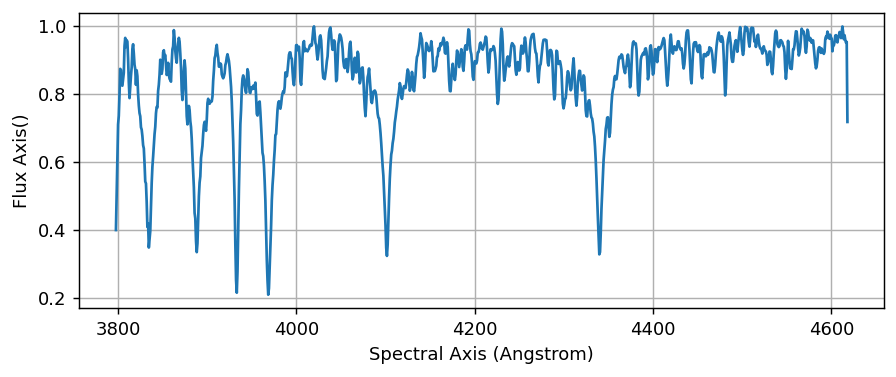

In [7]:
from matplotlib import pyplot as plt

spectrum = spec[3]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

ax.plot ( spectrum.spectral_axis, spectrum.flux ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

**3.** Ajustamos una línea particular

In [8]:
from astropy.modeling import models, fitting
from astropy import units as u

region = [ 4300, 4380 ] * u.AA
mask = ( spectrum.spectral_axis >= region[0] ) & ( spectrum.spectral_axis <= region[1] )  

x = spectrum.spectral_axis [ mask ] 
y = spectrum.flux [ mask ]

bg = models.Const1D ( amplitude = 1 )
gs = models.Gaussian1D ( amplitude = 1, mean = 4340, stddev = 5 )

init_model = bg - gs
fitter = fitting.LevMarLSQFitter()
fit_model = fitter ( init_model, spectrum.spectral_axis, spectrum.flux )  

y_fit = fit_model ( x )  

print ( fit_model )  

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] - [1]
Components: 
    [0]: <Const1D(amplitude=0.85732689 )>

    [1]: <Gaussian1D(amplitude=0.41298636 , mean=4340.32858206 Angstrom, stddev=6.07077942 Angstrom)>
Parameters:
       amplitude_0        amplitude_1           mean_1           stddev_1     
                                               Angstrom          Angstrom     
    ------------------ ------------------ ----------------- ------------------
    0.8573268929810572 0.4129863632933787 4340.328582063008 6.0707794210556365


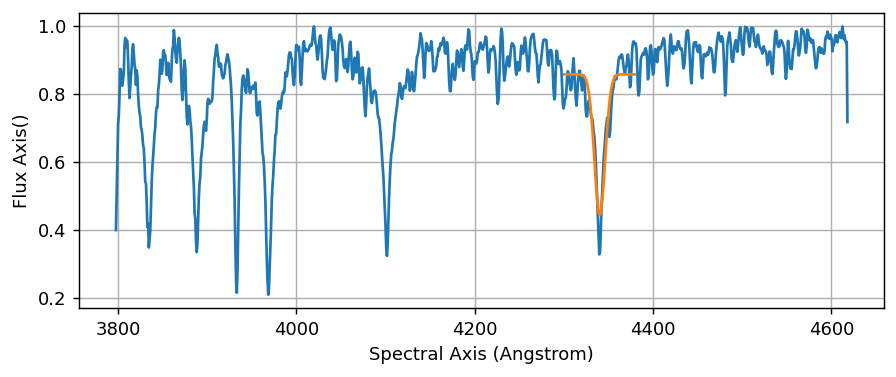

In [9]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.plot ( spectrum.spectral_axis, spectrum.flux) 
ax.plot ( x, y_fit )

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

¿Puede identificar líneas que estén presentes en los 10 espectros?

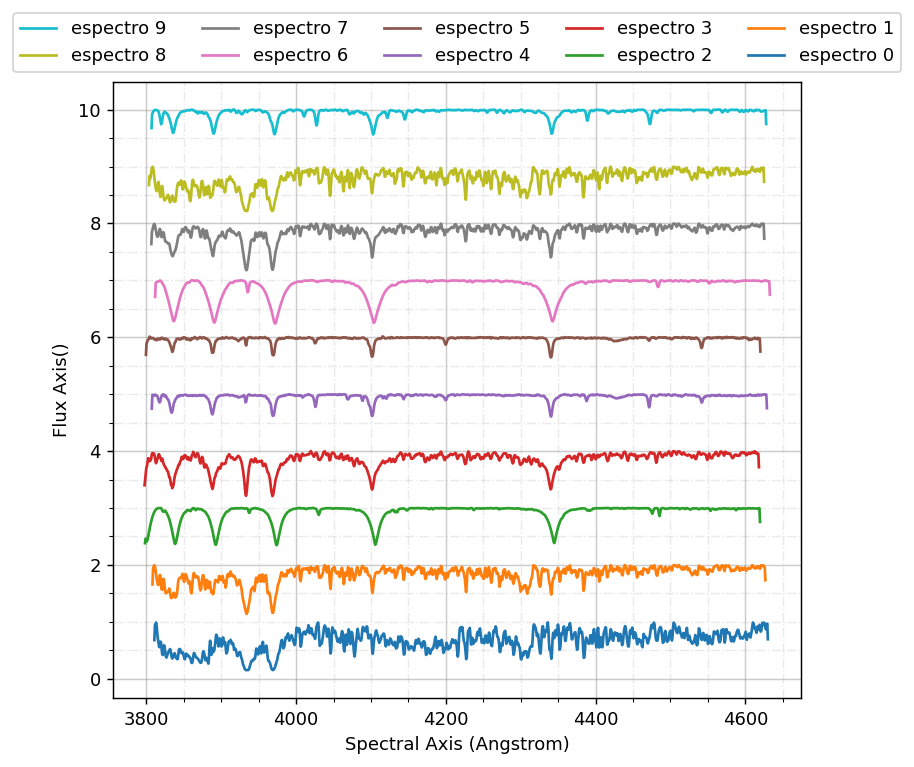

In [11]:
fig, ax = plt.subplots( figsize = (7, 6), dpi = 130 )

for i in range(0, 10):
    ax.plot ( spec[i].spectral_axis, spec[i].flux + i, label = "espectro %i" % (i) ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

# Show the major grid lines with dark grey lines
plt.grid ( which = 'major', color = '#999999', linestyle ='-', alpha = 0.5 )

# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid ( which = 'minor', color = '#999999', linestyle = '-.', alpha = 0.2 )

# Invierte el orden en el que muestra la legenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 5 )

fig.tight_layout()
plt.show()

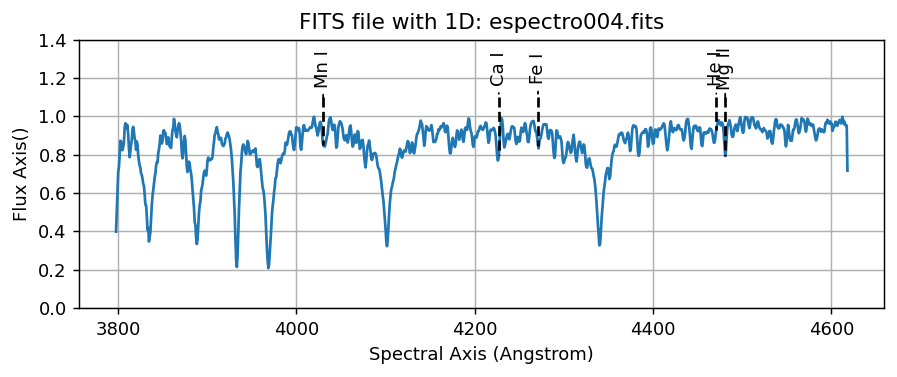

In [12]:
import matplotlib as mpl
import lineid_plot

n = 3
spectrum = spec[n]

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )

line_wave = [ 4030, 4227, 4271, 4471, 4481 ]
line_label = [ 'Mn I', 'Ca I', 'Fe I', 'He I', 'Mg II' ]

ax.plot ( spectrum.spectral_axis, spectrum.flux ) 
lineid_plot.plot_line_ids ( spectrum.spectral_axis, spectrum.flux, 
                           line_wave, line_label, 
                           arrow_tip = 1.1, box_loc = 1.25, ax = ax )

ax.set_title ( 'FITS file with 1D: ' + str(list[n]) )
ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

a = ax.findobj(mpl.text.Annotation)
for i in a:
    i.set_fontsize(10)
    
ax.set_ylim ( 0, 1.4 )
ax.grid ( True ) 
fig.tight_layout()
plt.show()